# E-Commerce Delivery Performance & Customer Experience Analysis

## Diagnostic Analysis using Python

### Project Overview

This notebook investigates the operational factors influencing delivery performance and customer experience in the Olist e-commerce marketplace.

While the SQL analysis focused on descriptive business metrics and key performance indicators, this notebook performs diagnostic analysis to identify relationships between delivery operations, customer satisfaction, seller performance, and product characteristics.

The insights generated from this analysis will help identify logistics bottlenecks, understand the drivers of customer satisfaction, and provide actionable business recommendations for improving marketplace performance.

## Section 1 — Project Setup

### Business Objective

Prepare a consolidated analytical dataset for performing diagnostic analysis on delivery performance and customer experience.

## Step 1.1 Import Libraries

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

import warnings 
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",10)

plt.style.use("ggplot")
sns.set_palette("Set2")

## Step 1.2 Load the Datasets

In [2]:
DATA_PATH = Path("../dataset")

customers = pd.read_csv(DATA_PATH/"olist_customers_dataset.csv")
orders = pd.read_csv(DATA_PATH/"olist_orders_dataset.csv")
order_items=pd.read_csv(DATA_PATH/"olist_order_items_dataset.csv")
payments=pd.read_csv(DATA_PATH/"olist_order_payments_dataset.csv")
products=pd.read_csv(DATA_PATH/"olist_products_dataset.csv")
reviews=pd.read_csv(DATA_PATH/"olist_order_reviews_dataset.csv")
sellers=pd.read_csv(DATA_PATH/"olist_sellers_dataset.csv")
geolocation=pd.read_csv(DATA_PATH/"olist_geolocation_dataset.csv")

## Step 1.3 Quick Dataset Overview

In [3]:
datasets={
  "Customers":customers,
  "Orders":orders,
  "Order Items":order_items,
  "Payments":payments,
  "Products":products,
  "Reviews":reviews,
  "Sellers":sellers,
  "Geolocation":geolocation
}

summary=pd.DataFrame({
    "Dataset": list(datasets.keys()),
    "Rows": [df.shape[0] for df in datasets.values()],
    "Columns": [df.shape[1] for df in datasets.values()],
    "Missing Values": [df.isna().sum().sum() for df in datasets.values()]
})

summary

,Dataset,Rows,Columns,Missing Values
0,Customers,99441,5,0
1,Orders,99441,8,4908
2,Order Items,112650,7,0
3,Payments,103886,5,0
4,Products,32951,9,2448
5,Reviews,99224,7,145903
6,Sellers,3095,4,0
7,Geolocation,1000163,5,0


### Observation

The Olist dataset consists of multiple normalized tables with varying record counts. Missing values are primarily observed in delivery-related timestamps and review comment fields.

Delivery date nulls correspond to orders that were not delivered or were canceled, while missing review comments indicate customers provided ratings without written feedback. These missing values are expected based on the business process.

The detailed data quality assessment was completed during the SQL phase. This notebook focuses on integrating the datasets and preparing them for diagnostic analysis.

## Section 2 — Data Preparation

### Business Objective

Prepare a consolidated analytical dataset by integrating multiple normalized tables and engineering new features required for diagnostic analysis.

## Step 2.1 Understanding Dataset Relationships

The Olist database follows a normalized relational structure, where business information is distributed across multiple tables. To perform diagnostic analysis, these tables must be integrated into a single analytical dataset.

The relationships between the tables are:

- Customers → Orders
- Orders → Order Items
- Orders → Payments
- Orders → Reviews
- Order Items → Products
- Order Items → Sellers

Since one order can contain multiple products and multiple payment records, careful data preparation is required to avoid duplicate records and ensure accurate analysis.

The final analytical dataset will combine customer, order, product, seller, payment, review, and delivery information into a unified DataFrame that serves as the foundation for all subsequent analyses.

## Step 2.2 Convert Date Columns

### Business Objective

Convert string-based date columns into datetime format to enable delivery time calculations and time-based analyses.

In [4]:
date_columns = [
  "order_purchase_timestamp",
  "order_approved_at",
  "order_delivered_carrier_date",
  "order_delivered_customer_date",
  "order_estimated_delivery_date"
]

for column in date_columns:
  orders[column]=pd.to_datetime(orders[column])

orders[date_columns].dtypes


order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

## Step 2.3 Create Delivery Features

### Business Objective

Engineer delivery-related features that measure shipping efficiency and delivery performance.

In [5]:
orders["delivery_time"]=(
  orders["order_delivered_customer_date"]-
    orders["order_purchase_timestamp"]
).dt.days

orders["estimated_delivery_time"]=(
  orders["order_estimated_delivery_date"]-
    orders["order_purchase_timestamp"]
).dt.days

orders["delivery_delay"]=(
  orders["order_delivered_customer_date"]-
    orders["order_estimated_delivery_date"]
).dt.days




In [6]:
orders[
  [
    "delivery_time",
    "estimated_delivery_time",
    "delivery_delay"

  ]
].head()

,delivery_time,estimated_delivery_time,delivery_delay
0,8.0,15,-8.0
1,13.0,19,-6.0
2,9.0,26,-18.0
3,13.0,26,-13.0
4,2.0,12,-10.0


## Step 2.4 Analyze Table Relationships Before Merging

### Business Objective

Understand the cardinality of each table relationship to ensure the master dataset is built without introducing duplicate records or incorrect aggregations.

#### Step 2.4.1 Verify Payment Records Per Order

In [7]:
payments.groupby("order_id").size().describe()

count    99440.000000
mean         1.044710
std          0.381166
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         29.000000
dtype: float64

#### Step 2.4.2 Check Orders with Multiple Payments

In [8]:
multiple_payments =(
  payments.groupby("order_id")
  .size()
  .reset_index(name="payment_count")
)

multiple_payments[multiple_payments["payment_count"]>1].head()

,order_id,payment_count
36,0016dfedd97fc2950e388d2971d718c7,2
73,002f19a65a2ddd70a090297872e6d64e,2
161,0071ee2429bc1efdc43aa3e073a5290e,2
215,009ac365164f8e06f59d18a08045f6c4,6
258,00b4a910f64f24dbcac04fe54088a443,2


#### Finding

Most orders contain a single payment record. However, some orders are split across multiple payment transactions, with a maximum of 29 payment records observed for a single order.

Since the Payments table has a one-to-many relationship with Orders, directly merging it into the master analytical dataset would duplicate order-item records and distort revenue, delivery, and product-level analyses.

Therefore, the Payments table will be excluded from the master dataset and only aggregated when payment-related analyses are required.

## Step 2.5 Build the Master Analytical Dataset

### Business Objective

Create a consolidated analytical dataset by integrating all relevant business tables while preserving the order-item level of analysis. This dataset will serve as the foundation for all subsequent diagnostic analyses.

#### Step 2.5.1 Merge Orders and Customers

In [9]:
print("Orders Shape:", orders.shape)

master_df=orders.merge(
  customers,
  on="customer_id",
  how="left"
)

print("Master Shape:", master_df.shape)

master_df.head()

Orders Shape: (99441, 11)
Master Shape: (99441, 15)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,estimated_delivery_time,delivery_delay,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,15,-8.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,19,-6.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,26,-18.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,26,-13.0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,12,-10.0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [10]:
print("Duplicated_rows:",master_df.duplicated().sum())

master_df.isna().sum()

Duplicated_rows: 0


order_id                       0
customer_id                    0
order_status                   0
order_purchase_timestamp       0
order_approved_at            160
                            ... 
delivery_delay              2965
customer_unique_id             0
customer_zip_code_prefix       0
customer_city                  0
customer_state                 0
Length: 15, dtype: int64

#### Finding

The Orders and Customers tables were successfully merged using `customer_id` without introducing duplicate records.

The row count remained unchanged, confirming that every order was successfully linked to its corresponding customer information.

The remaining missing values are inherited from the Orders table and are related to incomplete delivery or approval information rather than the merge process.

#### Step 2.5.2 Merge Order Items

In [11]:
print("Master_Shape_before:",master_df.shape)

master_df=master_df.merge(
  order_items,
  on="order_id",
  how="left"
)

print("Master_shape_after",master_df.shape)

master_df.head()

Master_Shape_before: (99441, 15)
Master_shape_after (113425, 21)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,estimated_delivery_time,delivery_delay,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,15,-8.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,19,-6.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,26,-18.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,26,-13.0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,12,-10.0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72


In [12]:
print("Duplicated_rows:",master_df.duplicated().sum())

master_df.isna().sum()

Duplicated_rows: 0


order_id                      0
customer_id                   0
order_status                  0
order_purchase_timestamp      0
order_approved_at           161
                           ... 
product_id                  775
seller_id                   775
shipping_limit_date         775
price                       775
freight_value               775
Length: 21, dtype: int64

#### 2.5.3 Merge Products

In [13]:
print("Master shape before:",master_df.shape)

master_df=master_df.merge(
  products[["product_id","product_category_name"]],
  on="product_id",
  how="left"
)

print("Master shape after:",master_df.shape)

master_df.head()

Master shape before: (113425, 21)
Master shape after: (113425, 22)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,estimated_delivery_time,delivery_delay,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,15,-8.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,19,-6.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,26,-18.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,26,-13.0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,12,-10.0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria


In [14]:
print("Duplicated_rows:",master_df.duplicated().sum())

master_df.isna().sum()

Duplicated_rows: 0


order_id                       0
customer_id                    0
order_status                   0
order_purchase_timestamp       0
order_approved_at            161
                            ... 
seller_id                    775
shipping_limit_date          775
price                        775
freight_value                775
product_category_name       2378
Length: 22, dtype: int64

#### Finding

The Products table was successfully merged using product_id, enriching the analytical dataset with product category information.

The row count remained unchanged after the merge, confirming that each product_id corresponds to a single product record and no duplicate rows were introduced.

A small number of missing product categories remain due to products without category information or orders without associated order items. These represent valid data conditions rather than merge errors.


#### 2.5.4 Merge Reviews

In [15]:
review_counts = reviews.groupby("order_id").size()

review_counts.value_counts().sort_index()

1    98126
2      543
3        4
Name: count, dtype: int64

In [16]:
duplicate_reviews = reviews[
    reviews["order_id"].duplicated(keep=False)
].sort_values("order_id")

duplicate_reviews.head(20)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
25612,89a02c45c340aeeb1354a24e7d4b2c1e,0035246a40f520710769010f752e7507,5,NaN,NaN,2017-08-29 00:00:00,2017-08-30 01:59:12
22423,2a74b0559eb58fc1ff842ecc999594cb,0035246a40f520710769010f752e7507,5,NaN,Estou acostumada a comprar produtos pelo barat...,2017-08-25 00:00:00,2017-08-29 21:45:57
22779,ab30810c29da5da8045216f0f62652a2,013056cfe49763c6f66bda03396c5ee3,5,NaN,NaN,2018-02-22 00:00:00,2018-02-23 12:12:30
68633,73413b847f63e02bc752b364f6d05ee9,013056cfe49763c6f66bda03396c5ee3,4,NaN,NaN,2018-03-04 00:00:00,2018-03-05 17:02:00
854,830636803620cdf8b6ffaf1b2f6e92b2,0176a6846bcb3b0d3aa3116a9a768597,5,NaN,NaN,2017-12-30 00:00:00,2018-01-02 10:54:06
...,...,...,...,...,...,...,...
38386,1dee9d450a2b8533d2085cef898ca4a2,03515a836bb855b03f7df9dee520a8fc,5,NaN,NaN,2018-02-06 00:00:00,2018-02-06 17:19:21
51527,f4bb9d6dd4fb6dcc2298f0e7b17b8e1e,03c939fd7fd3b38f8485a0f95798f1f6,4,NaN,NaN,2018-03-29 00:00:00,2018-03-30 00:29:09
8273,b04ed893318da5b863e878cd3d0511df,03c939fd7fd3b38f8485a0f95798f1f6,3,NaN,Um ponto negativo que achei foi a cobrança de ...,2018-03-20 00:00:00,2018-03-21 02:28:23
69438,405eb2ea45e1dbe2662541ae5b47e2aa,03c939fd7fd3b38f8485a0f95798f1f6,3,NaN,Seria ótimo se tivesem entregue os 3 (três) pe...,2018-03-06 00:00:00,2018-03-06 19:50:32


In [17]:
duplicate_reviews[
    [
        "order_id",
        "review_id",
        "review_score",
        "review_creation_date",
        "review_answer_timestamp"
    ]
].head(20)

,order_id,review_id,review_score,review_creation_date,review_answer_timestamp
25612,0035246a40f520710769010f752e7507,89a02c45c340aeeb1354a24e7d4b2c1e,5,2017-08-29 00:00:00,2017-08-30 01:59:12
22423,0035246a40f520710769010f752e7507,2a74b0559eb58fc1ff842ecc999594cb,5,2017-08-25 00:00:00,2017-08-29 21:45:57
22779,013056cfe49763c6f66bda03396c5ee3,ab30810c29da5da8045216f0f62652a2,5,2018-02-22 00:00:00,2018-02-23 12:12:30
68633,013056cfe49763c6f66bda03396c5ee3,73413b847f63e02bc752b364f6d05ee9,4,2018-03-04 00:00:00,2018-03-05 17:02:00
854,0176a6846bcb3b0d3aa3116a9a768597,830636803620cdf8b6ffaf1b2f6e92b2,5,2017-12-30 00:00:00,2018-01-02 10:54:06
...,...,...,...,...,...
38386,03515a836bb855b03f7df9dee520a8fc,1dee9d450a2b8533d2085cef898ca4a2,5,2018-02-06 00:00:00,2018-02-06 17:19:21
51527,03c939fd7fd3b38f8485a0f95798f1f6,f4bb9d6dd4fb6dcc2298f0e7b17b8e1e,4,2018-03-29 00:00:00,2018-03-30 00:29:09
8273,03c939fd7fd3b38f8485a0f95798f1f6,b04ed893318da5b863e878cd3d0511df,3,2018-03-20 00:00:00,2018-03-21 02:28:23
69438,03c939fd7fd3b38f8485a0f95798f1f6,405eb2ea45e1dbe2662541ae5b47e2aa,3,2018-03-06 00:00:00,2018-03-06 19:50:32


In [18]:
reviews.groupby("order_id")["review_score"].nunique().value_counts()

review_score
1    98471
2      202
Name: count, dtype: int64

In [19]:
reviews_latest = (
    reviews
    .sort_values("review_creation_date")
    .drop_duplicates(
        subset="order_id",
        keep="last"
    )
)

reviews_latest.shape

(98673, 7)

In [20]:
print("Master shape before:",master_df.shape)

master_df = master_df.merge(
    reviews_latest[
        [
            "order_id",
            "review_score"
        ]
    ],
    on="order_id",
    how="left"
)

print("Master Shape After:",master_df.shape)

master_df.head()

Master shape before: (113425, 22)


Master Shape After: (113425, 23)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,estimated_delivery_time,delivery_delay,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,15,-8.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,19,-6.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,26,-18.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,26,-13.0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,12,-10.0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,5.0


In [21]:
print("Duplicated rows:",master_df.duplicated().sum())

master_df.isna().sum()

Duplicated rows: 0


order_id                       0
customer_id                    0
order_status                   0
order_purchase_timestamp       0
order_approved_at            161
                            ... 
shipping_limit_date          775
price                        775
freight_value                775
product_category_name       2378
review_score                 961
Length: 23, dtype: int64

#### Findings

- The reviews dataset contains multiple reviews for some orders.
- Review analysis showed:
  - 98,126 orders have one review.
  - 543 orders have two reviews.
  - 4 orders have three reviews.
- Among these duplicate reviews, only 202 orders had different review scores, while the majority had identical scores.
- Since the objective is to create one record per order-item combination, keeping multiple reviews would create unnecessary duplicate records.
- The latest review (based on `review_creation_date`) was retained for each order using `drop_duplicates(keep="last")`.
- Only the `review_score` column was merged into the master dataset because it is sufficient for customer satisfaction analysis. Review text and timestamps were excluded to keep the master dataset compact.
- After merging, the dataset maintained one review score per order while preserving the one-to-many relationship between orders and order items.

#### 2.6 Merge Payments

In [22]:
payment_counts = payments.groupby("order_id").size()

payment_counts.value_counts().sort_index()

1     96479
2      2382
3       301
4       108
5        52
      ...  
19        2
21        1
22        1
26        1
29        1
Name: count, Length: 20, dtype: int64

In [23]:
payments["payment_type"].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [24]:
payments["payment_installments"].describe()

count    103886.000000
mean          2.853349
std           2.687051
min           0.000000
25%           1.000000
50%           1.000000
75%           4.000000
max          24.000000
Name: payment_installments, dtype: float64

In [25]:
payments_master = (
    payments
    .groupby("order_id", as_index=False)
    .agg({
        "payment_value": "sum",
        "payment_installments": "max",
        "payment_type": "first"
    })
)

payments_master.shape

(99440, 4)

In [26]:
print("Master shape Before:", master_df.shape)

master_df = master_df.merge(
    payments_master,
    on="order_id",
    how="left"
)

print("Master Shape After:", master_df.shape)

master_df.head()

Master shape Before: (113425, 23)
Master Shape After: (113425, 26)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,estimated_delivery_time,delivery_delay,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,review_score,payment_value,payment_installments,payment_type
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,15,-8.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,4.0,38.71,1.0,credit_card
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,19,-6.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,4.0,141.46,1.0,boleto
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,26,-18.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,5.0,179.12,3.0,credit_card
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,26,-13.0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,5.0,72.20,1.0,credit_card
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,12,-10.0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,5.0,28.62,1.0,credit_card


In [27]:
print("Duplicate rows:", master_df.duplicated().sum())

master_df.isna().sum().sort_values(ascending=False)

Duplicate rows: 0


order_delivered_customer_date    3229
delivery_time                    3229
delivery_delay                   3229
product_category_name            2378
order_delivered_carrier_date     1968
                                 ... 
order_status                        0
customer_state                      0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
Length: 26, dtype: int64

#### Findings
- Multiple payment records existed for some orders because customers could complete a purchase using multiple payment methods or installments.
- A payment-level dataset (`payments_master`) was created by aggregating payment information to one record per `order_id`.
- The aggregated dataset retained the total payment value, maximum number of installments, and primary payment type for each order.
- The payment summary was merged into the master dataset using a left join on `order_id`.
- The master dataset shape increased from **(113425, 23)** to **(113425, 26)**, indicating that three payment-related features were successfully added.
- The number of rows remained unchanged after merging, confirming that the one-to-many relationship in the payments table was handled correctly.
- Post-merge validation showed **0 duplicate rows**, confirming that the aggregation prevented row duplication.

#### 2.5.7 Merge Sellers

In [28]:
print("Seller rows:", sellers.shape)

print("\nDuplicate seller_id:",
      sellers["seller_id"].duplicated().sum())

Seller rows: (3095, 4)

Duplicate seller_id: 0


In [29]:
print("Master shape Before:", master_df.shape)

master_df = master_df.merge(
    sellers[
        [
            "seller_id",
            "seller_zip_code_prefix",
            "seller_city",
            "seller_state"
        ]
    ],
    on="seller_id",
    how="left"
)

print("Master Shape After:", master_df.shape)

master_df.head()

Master shape Before: (113425, 26)
Master Shape After: (113425, 29)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,estimated_delivery_time,delivery_delay,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,review_score,payment_value,payment_installments,payment_type,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,15,-8.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,4.0,38.71,1.0,credit_card,9350.0,maua,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,19,-6.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,4.0,141.46,1.0,boleto,31570.0,belo horizonte,SP
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,26,-18.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,5.0,179.12,3.0,credit_card,14840.0,guariba,SP
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,26,-13.0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,5.0,72.20,1.0,credit_card,31842.0,belo horizonte,MG
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,12,-10.0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,5.0,28.62,1.0,credit_card,8752.0,mogi das cruzes,SP


In [30]:
print("Duplicate rows:", master_df.duplicated().sum())

master_df.isna().sum().sort_values(ascending=False)

Duplicate rows: 0


order_delivered_customer_date    3229
delivery_time                    3229
delivery_delay                   3229
product_category_name            2378
order_delivered_carrier_date     1968
                                 ... 
order_estimated_delivery_date       0
order_id                            0
customer_id                         0
customer_state                      0
customer_city                       0
Length: 29, dtype: int64

#### Findings
- The sellers dataset contained one unique record for each `seller_id`, making it suitable for a direct one-to-many merge.
- Seller location attributes (`seller_zip_code_prefix`, `seller_city`, and `seller_state`) were merged into the master dataset using `seller_id`.
- The master dataset shape increased from **(113425, 26)** to **(113425, 29)** after adding three seller-related attributes.
- The total number of rows remained unchanged after the merge, confirming that each order item was matched to a single seller.
- Post-merge validation showed **0 duplicate rows**, indicating that the merge preserved data integrity.

In [31]:
print("="*60)
print("FINAL MASTER DATASET")
print("="*60)

print("Shape:", master_df.shape)

print("\nDuplicate rows:", master_df.duplicated().sum())

print("\nMissing values")
display(master_df.isna().sum().sort_values(ascending=False))

print("\nColumns:", len(master_df.columns))

FINAL MASTER DATASET
Shape: (113425, 29)

Duplicate rows: 0

Missing values


order_delivered_customer_date    3229
delivery_time                    3229
delivery_delay                   3229
product_category_name            2378
order_delivered_carrier_date     1968
                                 ... 
order_estimated_delivery_date       0
order_id                            0
customer_id                         0
customer_state                      0
customer_city                       0
Length: 29, dtype: int64


Columns: 29


### Final Master Dataset Summary

The master dataset was created by sequentially merging the Customers, Order Items, Products, Reviews, Payments, and Sellers datasets.

Final validation confirmed:

- No duplicate rows
- Expected dataset dimensions
- Missing values only in columns where absence is valid (delivery dates, product category, etc.)

This master dataset is now ready for Exploratory Data Analysis (EDA).

## Section 3 — Data Understanding

## 3.1 Review Score Distribution

### Objective
Understand the overall customer satisfaction by analyzing the distribution of review scores. This helps identify whether customers generally had positive or negative experiences with their orders.

In [32]:
master_df["review_score"].describe()

count    112464.000000
mean          4.017037
std           1.399847
min           1.000000
25%           4.000000
50%           5.000000
75%           5.000000
max           5.000000
Name: review_score, dtype: float64

In [33]:
review_count= (
                master_df["review_score"]
                .value_counts()
                .sort_index()
              )

review_count


review_score
1.0    14683
2.0     3907
3.0     9429
4.0    21237
5.0    63208
Name: count, dtype: int64

In [34]:
review_percent=(
              master_df["review_score"]
              .value_counts(normalize=True)
              .sort_index()
              *100
).round(2)

review_percent

review_score
1.0    13.06
2.0     3.47
3.0     8.38
4.0    18.88
5.0    56.20
Name: proportion, dtype: float64

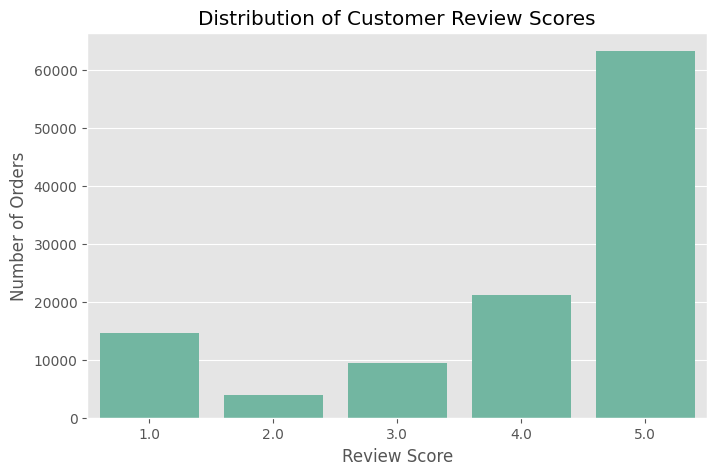

In [35]:
plt.figure(figsize=(8,5))

sns.countplot(
  data=master_df,
  x="review_score",
  order=sorted(master_df["review_score"].dropna().unique())
)

plt.title("Distribution of Customer Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Number of Orders")

plt.show()

#### Findings

- A total of **112,464 orders** had valid customer review scores, with an average rating of **4.02 out of 5**, indicating generally positive customer satisfaction.
- The **median review score was 5**, showing that at least half of all reviewed orders received the highest possible rating.
- **5-star reviews dominated the dataset**, accounting for **63,208 orders (56.20%)**, followed by **4-star reviews (18.88%)**.
- Lower ratings were comparatively less common, with **1-star reviews representing 13.06%** of all reviews and **2-star reviews only 3.47%**.
- The review score distribution is **positively skewed toward higher ratings**, suggesting that most customers were satisfied with their overall shopping and delivery experience.

## 3.2 Delivery Time Distribution

### Objective

Analyze the overall delivery time to understand how long orders take to reach customers and identify the spread and variability in delivery durations.

In [36]:
master_df["delivery_time"].describe()

count    110196.000000
mean         12.007723
std           9.451455
min           0.000000
25%           6.000000
50%          10.000000
75%          15.000000
max         209.000000
Name: delivery_time, dtype: float64

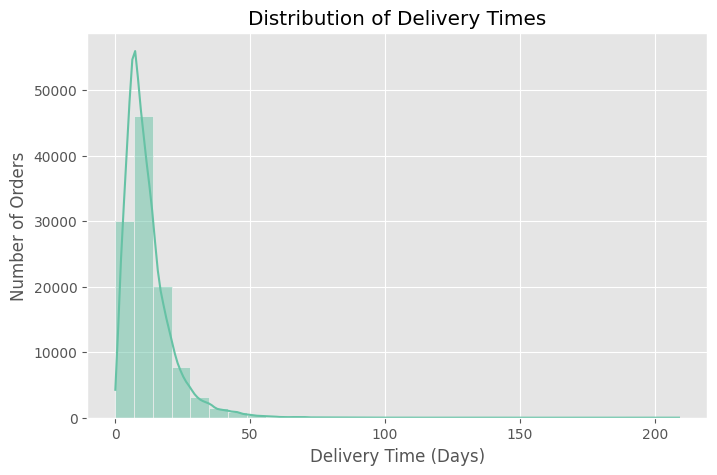

In [37]:
plt.figure(figsize=(8,5))

sns.histplot(
  data=master_df,
  x="delivery_time",
  bins=30,
  kde=True
)

plt.title("Distribution of Delivery Times")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Orders")

plt.show()

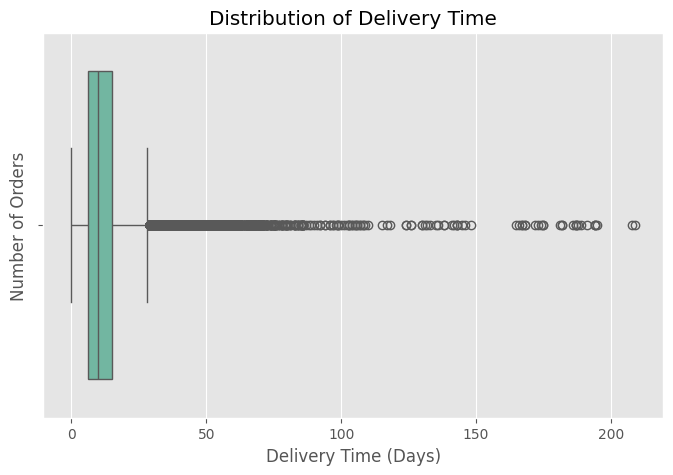

In [38]:
plt.figure(figsize=(8,5))

sns.boxplot(
  data=master_df,
  x="delivery_time"
)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Orders")

plt.show()

#### Findings

- The average delivery time was **12.01 days**, while the median delivery time was **10 days**, indicating that most orders were delivered within approximately two weeks.
- The distribution of delivery time is **positively skewed (right-skewed)**, with the majority of orders delivered between **5 and 15 days**.
- The maximum delivery time reached **209 days**, highlighting the presence of extreme delivery delays.
- The histogram and box plot reveal a **large number of high-value outliers**, indicating that although most deliveries were completed within a reasonable time, a small proportion experienced exceptionally long delivery durations.
- The difference between the mean (12.01 days) and the median (10 days) further confirms that a relatively small number of delayed deliveries increased the overall average delivery time.

## 3.3 Delivery Delay Distribution

### Objective

Analyze the distribution of delivery delays to understand how often orders were delivered early, on time, or late, and identify the presence of extreme delivery delays.

In [39]:
master_df["delivery_delay"].describe()

count    110196.000000
mean        -12.030201
std          10.160157
min        -147.000000
25%         -17.000000
50%         -13.000000
75%          -7.000000
max         188.000000
Name: delivery_delay, dtype: float64

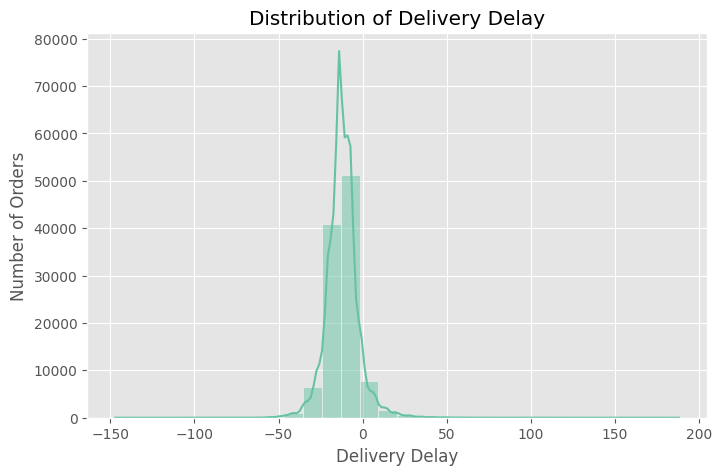

In [40]:
plt.figure(figsize=(8,5))

sns.histplot(
  data=master_df,
  x="delivery_delay",
  bins=30,
  kde=True
)

plt.title("Distribution of Delivery Delay")
plt.xlabel("Delivery Delay")
plt.ylabel("Number of Orders")

plt.show()

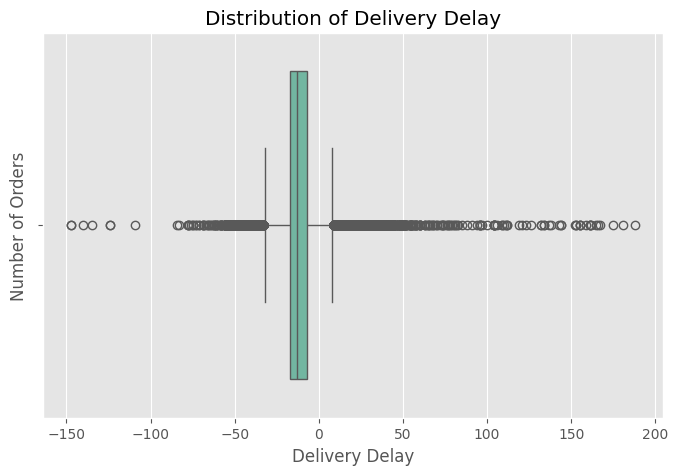

In [41]:
plt.figure(figsize=(8,5))

sns.boxplot(
  data=master_df,
  x="delivery_delay"
)

plt.title("Distribution of Delivery Delay")
plt.xlabel("Delivery Delay")
plt.ylabel("Number of Orders")

plt.show()

#### Findings

- The average delivery delay was **-12.03 days**, indicating that most orders were delivered approximately **12 days earlier than the estimated delivery date**.

- The median delivery delay was **-13 days**, while 75% of orders were delivered **at least 7 days before** the promised date, showing consistently early deliveries.

- The distribution is **centered around negative values**, confirming that early deliveries were far more common than late deliveries.

- The histogram shows a **roughly bell-shaped distribution** around the peak with **long tails on both sides**, indicating a few orders experienced extremely early or significantly delayed deliveries.

- The box plot highlights the presence of **outliers in both directions**, with some orders delivered **more than 100 days early** and others delayed by **over 180 days**. These extreme cases warrant further investigation in the Delivery Performance Diagnostics section.

## 3.4 Freight Cost Distribution

### Objective

Analyze the distribution of freight charges to understand shipping cost patterns, identify the typical freight cost paid by customers, and detect unusually high shipping charges.

In [42]:
master_df["freight_value"].describe()

count    112650.000000
mean         19.990320
std          15.806405
min           0.000000
25%          13.080000
50%          16.260000
75%          21.150000
max         409.680000
Name: freight_value, dtype: float64

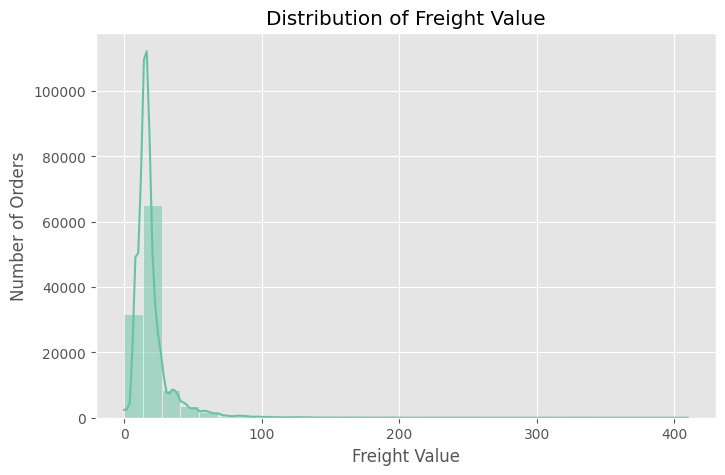

In [43]:
plt.figure(figsize=(8,5))

sns.histplot(
  data=master_df,
  x="freight_value",
  bins=30,
  kde=True
)

plt.title("Distribution of Freight Value")
plt.xlabel("Freight Value")
plt.ylabel("Number of Orders")

plt.show()

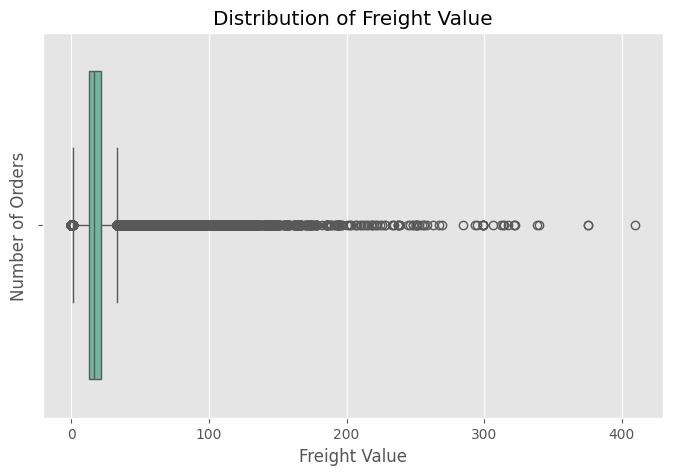

In [44]:
plt.figure(figsize=(8,5))

sns.boxplot(
  data=master_df,
  x="freight_value",

)

plt.title("Distribution of Freight Value")
plt.xlabel("Freight Value")
plt.ylabel("Number of Orders")

plt.show()

#### Findings

- The average freight cost was **19.99**, while the median freight cost was **16.26**, indicating that most orders incurred relatively low shipping charges.

- Approximately **50% of orders** had freight charges between **13.08 and 21.15**, suggesting that shipping costs were generally concentrated within a narrow range.

- The freight cost distribution is **highly right-skewed**, with the majority of orders having low shipping costs and a small number of orders incurring substantially higher freight charges.

- The histogram shows that **most freight charges are below 50**, while only a limited number of orders have freight costs exceeding 100.

- The box plot reveals **numerous high-value outliers**, with the maximum freight charge reaching **409.68**. These unusually expensive shipments may be associated with long-distance deliveries, bulky products, or special logistics requirements and should be explored further in later analyses.

## 3.5 Order Value Distribution

### Objective

Analyze the distribution of product prices to understand the typical order value, identify pricing patterns, and detect unusually expensive orders.

In [45]:
master_df["price"].describe()

count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64

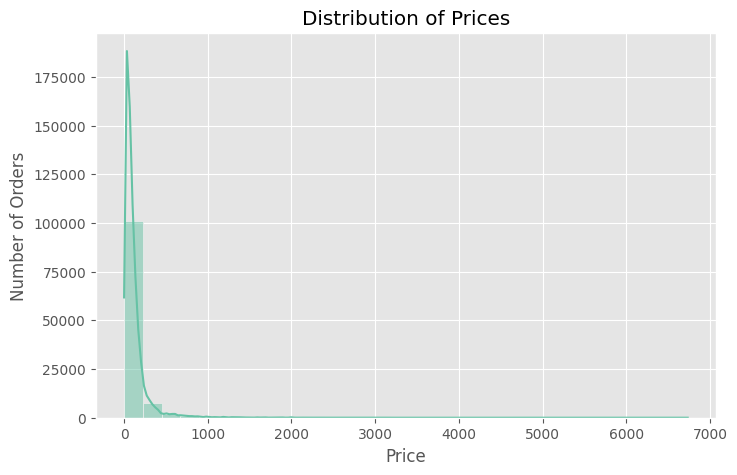

In [46]:
plt.figure(figsize=(8,5))

sns.histplot(
  data=master_df,
  x="price",
  bins=30,
  kde=True
)

plt.title("Distribution of Prices")
plt.xlabel("Price")
plt.ylabel("Number of Orders")

plt.show()

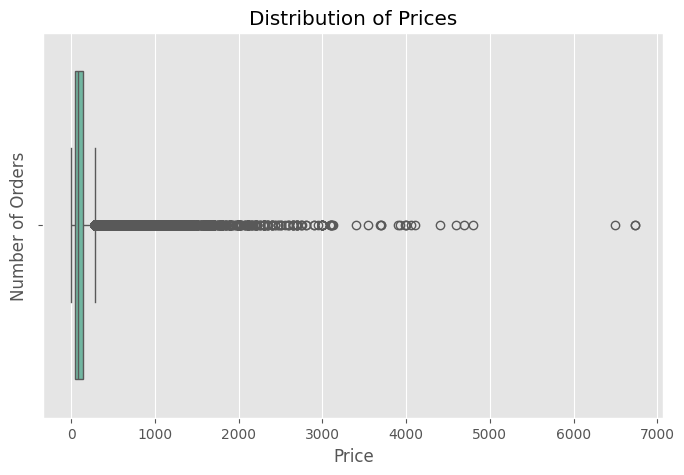

In [47]:
plt.figure(figsize=(8,5))

sns.boxplot(
  data=master_df,
  x="price"
)

plt.title("Distribution of Prices")
plt.xlabel("Price")
plt.ylabel("Number of Orders")

plt.show()

#### Findings

- The average product price was **120.65**, while the median price was **74.99**, indicating that most purchased products were relatively affordable, with a smaller number of high-priced items increasing the average.

- Approximately **50% of product prices** ranged between **39.90 and 134.90**, showing that the majority of products were sold within a moderate price range.

- The price distribution is **highly right-skewed**, with a large concentration of low- to mid-priced products and a long tail of expensive items.

- The histogram shows that **most products were priced below 500**, while only a small proportion of products had substantially higher prices.

- The box plot highlights **numerous high-price outliers**, with the most expensive product priced at **6,735.00**. These premium-priced products represent a very small fraction of all orders and may belong to luxury or specialized product categories.

## Section 4 — Delivery Performance Diagnostics


## 4.1 Delivery Delay Outlier Analysis

### Objective

Identify extreme delivery delays using the IQR method to understand how many orders experienced unusually early or unusually late deliveries and determine whether these outliers represent exceptional business cases requiring further investigation.

In [48]:
delay = master_df["delivery_delay"].dropna()

In [49]:
Q1 = np.percentile(delay,25)
Q3 = np.percentile(delay,75)

IQR = Q3-Q1
LB = Q1-1.5*IQR
UB = Q3+1.5*IQR

print("Q1:",Q1)
print("Q3:",Q3)

print("InterQuartile Range:",IQR)
print("Lower Bound:",LB)
print("Upper Bound:",UB)



Q1: -17.0
Q3: -7.0
InterQuartile Range: 10.0
Lower Bound: -32.0
Upper Bound: 8.0


In [50]:
outliers=master_df[
         (master_df["delivery_delay"]<LB)|
         (master_df["delivery_delay"]>UB)
]

print("Number of Outliers:",len(outliers))
print("Percentage of Outliers:",round((len(outliers)/len(delay)*100),2),"%")

outliers.head()

Number of Outliers: 4926
Percentage of Outliers: 4.47 %


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,estimated_delivery_time,delivery_delay,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,review_score,payment_value,payment_installments,payment_type,seller_zip_code_prefix,seller_city,seller_state
21,203096f03d82e0dffbc41ebc2e2bcfb7,d2b091571da224a1b36412c18bc3bbfe,delivered,2017-09-18 14:31:30,2017-09-19 04:04:09,2017-10-06 17:50:03,2017-10-09 22:23:46,2017-09-28,21.0,9,11.0,d699688533772c15a061e8ce81cb56df,4001,sao paulo,SP,1.0,5ac9d9e379c606e36a8094a6046f75dc,633ecdf879b94b5337cca303328e4a25,2017-09-25 04:04:09,109.90,8.96,beleza_saude,2.0,118.86,1.0,boleto,4438.0,sao paulo,SP
26,fbf9ac61453ac646ce8ad9783d7d0af6,3a874b4d4c4b6543206ff5d89287f0c3,delivered,2018-02-20 23:46:53,2018-02-22 02:30:46,2018-02-26 22:25:22,2018-03-21 22:03:54,2018-03-12,28.0,19,9.0,a25d5f94840d3c6a1a49f271ed83f4ec,21715,rio de janeiro,RJ,1.0,7b717060aa783eb7f23a747a3a733dd7,c0563dd588b775f2e37747ef6ad6c92c,2018-02-28 02:30:44,109.90,15.53,cool_stuff,2.0,125.43,1.0,boleto,9220.0,santo andre,SP
112,6a0a8bfbbe700284feb0845d95e0867f,68451b39b1314302c08c65a29f1140fc,delivered,2017-11-22 11:32:22,2017-11-22 11:46:50,2017-11-27 13:39:35,2017-12-28 19:43:00,2017-12-11,36.0,18,17.0,781ae350edb16842380e81d7c7feb431,20740,rio de janeiro,RJ,1.0,f8a8f05a35976a91aed5cccc3992c357,4a3ca9315b744ce9f8e9374361493884,2017-11-28 11:46:50,83.90,17.84,moveis_decoracao,1.0,101.74,5.0,credit_card,14940.0,ibitinga,SP
114,23f553848a03aaab35bb3f9f87725125,c622b892a190735ef81c0087973fa16d,delivered,2018-06-05 09:10:34,2018-06-05 09:32:22,2018-06-06 15:37:00,2018-06-18 12:36:54,2018-07-23,13.0,47,-35.0,439ced9aafa171a1ac88efa951c7db0a,85618,flor da serra do sul,PR,1.0,cac9e5692471a0700418aa3400b9b2b1,36890be00bbfc1cdb9a4a38a6af05a69,2018-06-15 09:31:23,99.20,18.57,bebes,5.0,117.77,2.0,credit_card,6040.0,osasco,SP
125,9d531c565e28c3e0d756192f84d8731f,d4faa220408c20e53595d2950f361f3b,delivered,2017-11-28 21:00:44,2017-12-01 09:31:15,2017-12-14 20:37:43,2018-01-23 21:38:52,2017-12-22,56.0,23,32.0,efc37ae565ee0943cca2b89fc65c4d6f,24933,marica,RJ,1.0,807b2de93dbb064bbc82dc6ac963bc61,903037660cf848a717166eb7a06d616e,2017-12-06 20:57:24,25.99,14.10,moveis_decoracao,1.0,40.09,4.0,credit_card,5734.0,sao paulo,SP


In [51]:
early_delivery_delays=master_df[(master_df["delivery_delay"]<LB)]
late_delivery_delays=master_df[(master_df["delivery_delay"]>UB)]

print("Early Delivery Delays:",len(early_delivery_delays))
print("Late Delivery Delays:",len(late_delivery_delays))

Early Delivery Delays: 2156
Late Delivery Delays: 2770


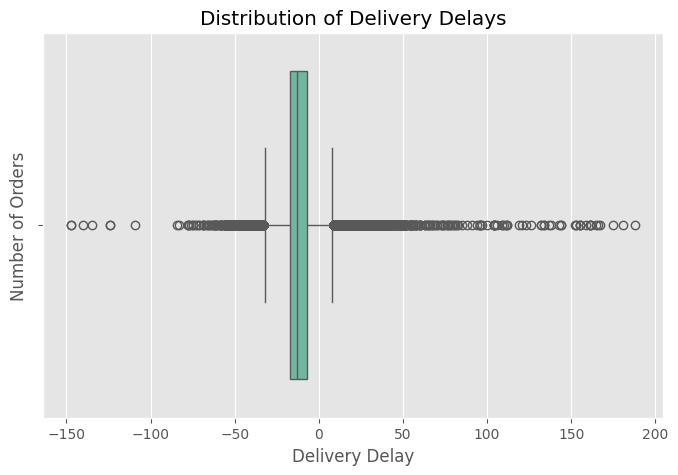

In [52]:
plt.figure(figsize=(8,5))

sns.boxplot(
  data=master_df,
  x="delivery_delay"
)

plt.title("Distribution of Delivery Delays")
plt.xlabel("Delivery Delay")
plt.ylabel("Number of Orders")

plt.show()

#### Findings

- Using the IQR method, the lower bound for delivery delay was **-32 days** and the upper bound was **8 days**.
- A total of **4,926 orders (4.47%)** were identified as delivery delay outliers.
- Among these outliers, **2,156 orders** were delivered **more than 32 days earlier** than the estimated delivery date.
- **2,770 orders** were delivered **more than 8 days later** than the estimated delivery date.
- The presence of more extreme late deliveries than extreme early deliveries indicates that severe delivery delays occurred more frequently than exceptionally early deliveries.
- These outliers represent important operational events rather than data errors and will be examined further in subsequent delivery performance analyses.

## 3.2 Delivery Performance Variability by State

### Objective

Analyze delivery performance across customer states to identify regions with consistently faster or slower deliveries and uncover geographical differences in logistics efficiency.

In [53]:
average_delivery_delay_by_customer_state=master_df.groupby("customer_state")["delivery_delay"].mean().sort_values(ascending=False).reset_index()

average_delivery_delay_by_customer_state 

,customer_state,delivery_delay
0,AL,-8.735363
1,MA,-9.906250
2,SE,-10.002667
3,ES,-10.646292
4,BA,-10.982623
...,...,...
22,RR,-18.326087
23,AP,-18.395062
24,AM,-19.932515
25,RO,-20.040293


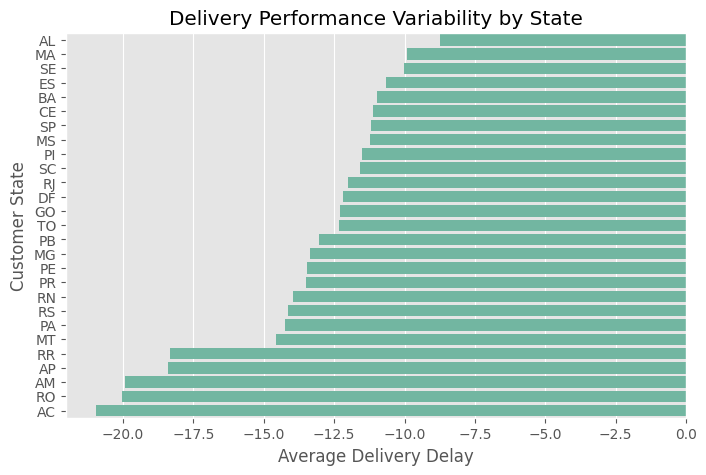

In [54]:
plt.figure(figsize=(8,5))

sns.barplot(
  data=average_delivery_delay_by_customer_state,
  x="delivery_delay",
  y="customer_state",
  orient="h"
)

plt.title("Delivery Performance Variability by State")
plt.xlabel("Average Delivery Delay")
plt.ylabel("Customer State")

plt.show()

#### Findings

- Delivery performance varies considerably across customer states, with average delivery delays ranging from approximately **-8.7 days to -21.0 days**.
- **Alagoas (AL)** has the highest average delivery delay at approximately **-8.7 days**, indicating that deliveries were generally early but by a smaller margin compared with other states.
- **Maranhão (MA)** and **Sergipe (SE)** also show relatively smaller early-delivery margins, at approximately **-9.9 and -10.0 days** respectively.
- **Acre (AC)** shows the largest early-delivery margin at approximately **-21.0 days**, followed by **Rondônia (RO)** at around **-20.0 days** and **Amazonas (AM)** at around **-19.9 days**.
- The results indicate **clear geographical variation in delivery performance**, suggesting differences in logistics efficiency, transportation distance, or regional delivery conditions.
- The average delivery delay is **negative across all states**, meaning that orders were delivered **before the estimated delivery date** on average in every state.
- States with smaller negative values can be considered relatively **slower performers**, while states with larger negative values represent **earlier deliveries**.
- Overall, the findings highlight **regional differences in delivery performance** and suggest that state-level logistics factors may influence delivery efficiency.

## 3.3 Freight Cost vs Delivery Time

### Objective

Analyze whether higher freight costs are associated with longer delivery times, and identify whether expensive shipping is actually resulting in slower deliveries.

In [55]:
master_df[["freight_value", "delivery_time"]].describe()

,freight_value,delivery_time
count,112650.000000,110196.000000
mean,19.990320,12.007723
std,15.806405,9.451455
min,0.000000,0.000000
25%,13.080000,6.000000
50%,16.260000,10.000000
75%,21.150000,15.000000
max,409.680000,209.000000


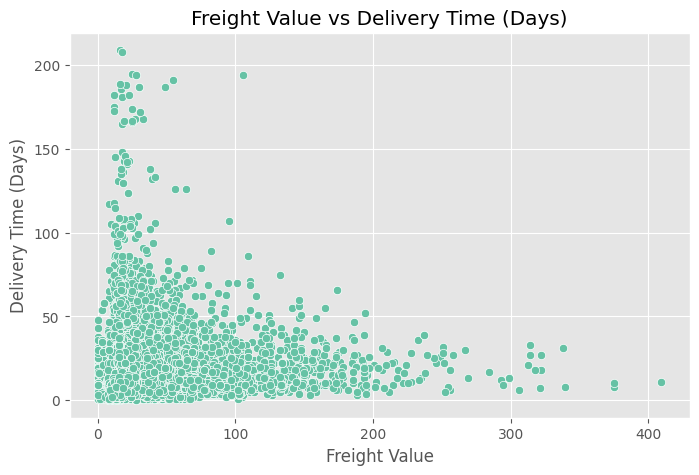

In [56]:
plt.figure(figsize=(8,5))

sns.scatterplot(
  data=master_df,
  x="freight_value",
  y="delivery_time"
)

plt.title("Freight Value vs Delivery Time (Days)")
plt.xlabel("Freight Value")
plt.ylabel("Delivery Time (Days)")

plt.show()

In [57]:
master_df[["freight_value", "delivery_time"]].corr()

,freight_value,delivery_time
freight_value,1.000000,0.214631
delivery_time,0.214631,1.000000


#### Findings

- The scatter plot shows a weak positive relationship between freight value and delivery time.
- The correlation coefficient between freight value and delivery time is **0.215**, indicating a weak positive correlation.
- Most orders have relatively low freight values and are delivered within approximately **50 days**.
- Several extreme delivery times occur even at relatively low freight values, indicating that high delivery times are not limited to high-freight orders.
- The weak correlation suggests that **freight cost alone is not a major driver of delivery time**.
- Other operational factors, such as geographic location, seller performance, product category, and logistics conditions, may have a stronger influence on delivery duration.

## 3.4 Delivery Time by Product Category

### Objective

Analyze average delivery time across product categories to identify categories with consistently faster or slower deliveries and determine whether certain product types experience greater delivery delays.

In [58]:
average_delivery_time_by_product_category=master_df.groupby("product_category_name")["delivery_time"].mean().sort_values(ascending=False).reset_index()

average_delivery_time_by_product_category

,product_category_name,delivery_time
0,moveis_escritorio,20.386691
1,artigos_de_natal,15.300000
2,seguros_e_servicos,15.000000
3,fashion_calcados,14.933852
4,casa_conforto_2,14.066667
...,...,...
68,fashion_roupa_infanto_juvenil,8.142857
69,portateis_cozinha_e_preparadores_de_alimentos,7.785714
70,livros_importados,7.666667
71,la_cuisine,7.071429


In [62]:
top_10_avergae_delivery_time_by_product_category=average_delivery_time_by_product_category.head(10)

top_10_avergae_delivery_time_by_product_category

,product_category_name,delivery_time
0,moveis_escritorio,20.386691
1,artigos_de_natal,15.300000
2,seguros_e_servicos,15.000000
3,fashion_calcados,14.933852
4,casa_conforto_2,14.066667
5,moveis_colchao_e_estofado,13.891892
6,eletrodomesticos_2,13.424242
7,moveis_sala,13.294949
8,fashion_underwear_e_moda_praia,13.275591
9,ferramentas_jardim,13.231959


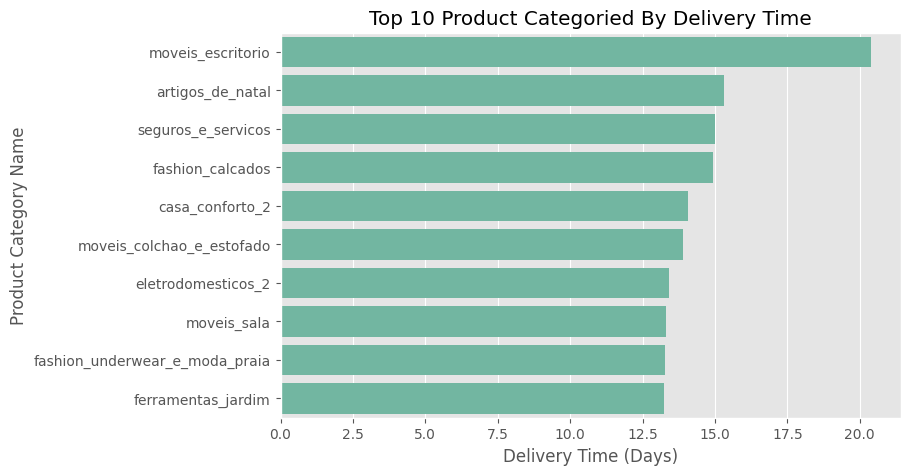

In [66]:
plt.figure(figsize=(8,5))

sns.barplot(
  data=top_10_avergae_delivery_time_by_product_category,
  x="delivery_time",
  y="product_category_name",
  orient="h"
)

plt.title("Top 10 Product Categoried By Delivery Time")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Product Category Name")

plt.show()

In [65]:
bottom_10_avergae_delivery_time_by_product_category=average_delivery_time_by_product_category.tail(10)

bottom_10_avergae_delivery_time_by_product_category

,product_category_name,delivery_time
63,portateis_casa_forno_e_cafe,9.397260
64,construcao_ferramentas_iluminacao,9.245847
65,alimentos,9.100200
66,artigos_de_festas,8.904762
67,pc_gamer,8.750000
68,fashion_roupa_infanto_juvenil,8.142857
69,portateis_cozinha_e_preparadores_de_alimentos,7.785714
70,livros_importados,7.666667
71,la_cuisine,7.071429
72,artes_e_artesanato,5.291667


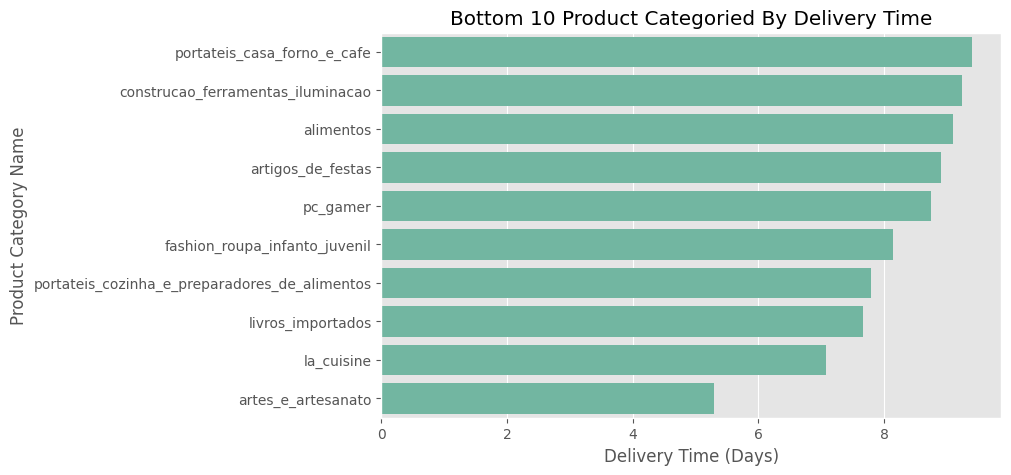

In [67]:
plt.figure(figsize=(8,5))

sns.barplot(
  data=bottom_10_avergae_delivery_time_by_product_category,
  x="delivery_time",
  y="product_category_name",
  orient="h"
)

plt.title("Bottom 10 Product Categoried By Delivery Time")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Product Category Name")

plt.show()

#### Findings

- The average delivery time varies considerably across product categories.
- The `moveis_escritorio` category has the highest average delivery time at approximately **20.39 days**.
- Other categories with relatively high delivery times include `artigos_de_natal`, `seguros_e_servicos`, and `fashion_calcados`.
- Among the fastest categories, `artes_e_artesanato` has the lowest average delivery time at approximately **5.29 days**.
- The difference between the slowest and fastest categories indicates that product category is associated with substantial variation in delivery time.
- Categories with consistently longer delivery times may require further investigation into product characteristics, seller location, fulfillment processes, or logistics constraints.

## Section 4 — Customer Experience Diagnostics

## 4.1 Delivery Delay vs Review Score

### Objective

Analyze the relationship between delivery delays and customer review scores to determine whether longer delivery delays are associated with lower customer satisfaction.

In [68]:
average_delivery_delay_by_review_score=master_df.groupby("review_score")["delivery_delay"].mean().sort_values(ascending=False).reset_index()

average_delivery_delay_by_review_score

,review_score,delivery_delay
0,1.0,-5.944524
1,2.0,-9.749115
2,3.0,-11.068609
3,4.0,-12.483514
4,5.0,-13.420992


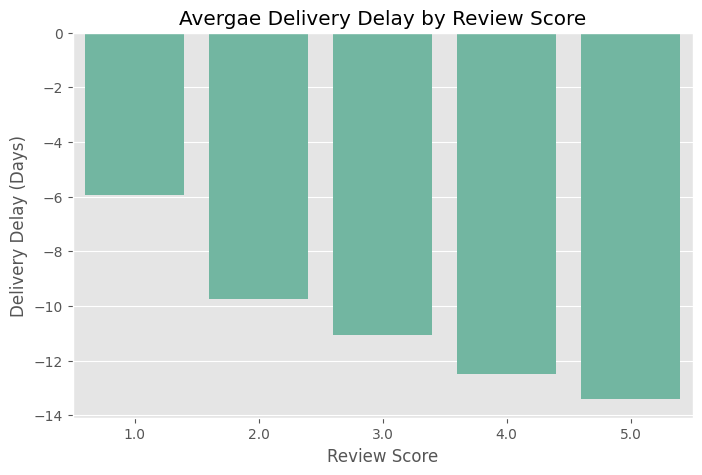

In [69]:
plt.figure(figsize=(8,5))

sns.barplot(
  data=average_delivery_delay_by_review_score,
  x="review_score",
  y="delivery_delay"
)

plt.title("Avergae Delivery Delay by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Delivery Delay (Days)")

plt.show()

#### Findings

- Average delivery delay varies consistently across customer review scores.
- Customers giving **1-star reviews** experienced the least early delivery, with an average delivery delay of approximately **-5.94 days**.
- Customers giving **5-star reviews** experienced the earliest deliveries, with an average delivery delay of approximately **-13.42 days**.
- The average delivery delay becomes progressively more negative as the review score increases, indicating that higher-rated orders were generally delivered earlier relative to the estimated delivery date.
- The difference between 1-star and 5-star reviews is approximately **7.48 days**, suggesting a meaningful association between delivery performance and customer satisfaction.
- Overall, the results indicate that **faster delivery is associated with higher customer review scores**.
- This analysis shows an association between delivery performance and review score and does not by itself establish a causal relationship.

## 4.2 Review Score by Delivery Status

### Objective

Analyze customer review scores across different delivery statuses to determine whether early, on-time, or late deliveries are associated with differences in customer satisfaction.

In [ ]:
delivery_status = np.select(
    [
        master_df["delivery_delay"] < 0,
        master_df["delivery_delay"] == 0,
        master_df["delivery_delay"] > 0
    ],
    [
        "Early",
        "On-Time",
        "Late"
    ],
    default="Unknown"
)

master_df["delivery_status"] = delivery_status

In [73]:
master_df["delivery_status"].value_counts()

delivery_status
Early      101481
Late         7265
Unknown      3229
On-Time      1450
Name: count, dtype: int64

In [78]:
average_review_score_by_delivery_status=master_df.groupby("delivery_status")["review_score"].mean().sort_values(ascending=False).reset_index()

average_review_score_by_delivery_status

,delivery_status,review_score
0,Early,4.211098
1,On-Time,3.983983
2,Late,2.256494
3,Unknown,1.738611


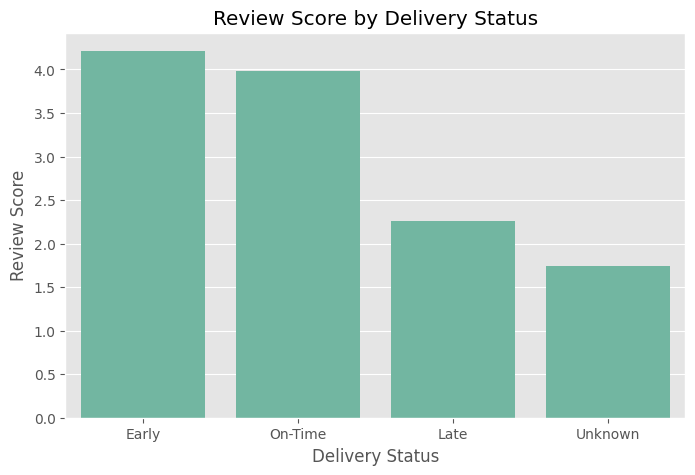

In [79]:
plt.figure(figsize=(8,5))

sns.barplot(
  data=average_review_score_by_delivery_status,
  x="delivery_status",
  y="review_score"
)

plt.title("Review Score by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Review Score")

plt.show()

#### Findings

- Customers whose orders were delivered early had the highest average review score of **4.21**.
- On-time deliveries received an average review score of **3.98**, slightly lower than early deliveries.
- Late deliveries had a substantially lower average review score of **2.26**, indicating a strong negative association between late delivery and customer satisfaction.
- Orders with an **Unknown** delivery status had the lowest average review score of **1.74**; however, these records contain missing delivery-delay information and should not be interpreted as a valid delivery-status category.
- The clear decline in review scores from early/on-time deliveries to late deliveries indicates that **delivery performance is strongly associated with customer satisfaction**.
- Late deliveries therefore represent an important area for operational improvement, as reducing delivery delays may help improve customer experience and review scores.

## 4.3 Average Delivery Delay by Review Category

### Objective

Analyze average delivery delay across different customer review categories to determine whether lower-rated orders are associated with greater delivery delays.

In [80]:
review_category=np.select(
  [
    master_df["review_score"]<3,
    master_df["review_score"]==3,
    master_df["review_score"]>3
  ],
  [
    "Low",
    "Neutral",
    "High"
  ],
  default="Unknown"
)

master_df["review_category"]=review_category

In [81]:
master_df["review_category"].value_counts()

review_category
High       84445
Low        18590
Neutral     9429
Unknown      961
Name: count, dtype: int64

In [82]:
average_delivery_delay_by_review_category=master_df.groupby("review_category")["delivery_delay"].mean().sort_values(ascending=False).reset_index()

average_delivery_delay_by_review_category

,review_category,delivery_delay
0,Low,-6.808637
1,Unknown,-7.389359
2,Neutral,-11.068609
3,High,-13.185766


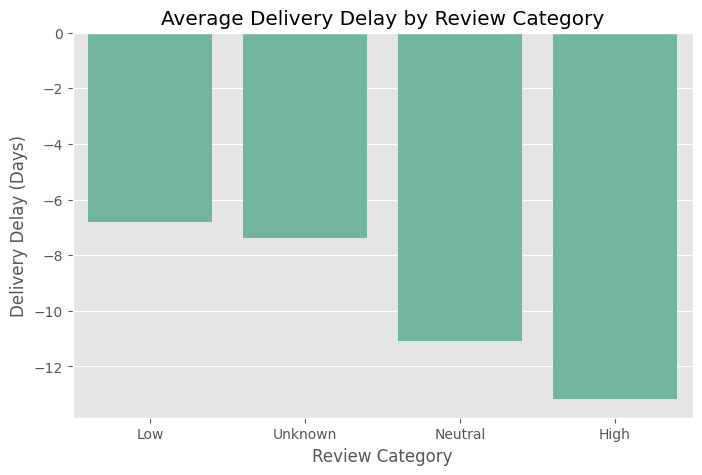

In [84]:
plt.figure(figsize=(8,5))

sns.barplot(
  data=average_delivery_delay_by_review_category,
  x="review_category",
  y="delivery_delay"
)

plt.title("Average Delivery Delay by Review Category")
plt.xlabel("Review Category")
plt.ylabel("Delivery Delay (Days)")

plt.show()

#### Findings

- The **High review category** had the lowest average delivery delay of **−13.19 days**, indicating that these orders were delivered substantially earlier than estimated.
- The **Neutral review category** had an average delivery delay of **−11.07 days**, also indicating relatively early deliveries.
- Orders in the **Unknown** review category had an average delivery delay of **−7.39 days**; however, these records have unavailable review scores and should not be treated as a meaningful review category.
- The **Low review category** had the highest average delivery delay of **−6.81 days**, meaning these orders were delivered earlier by a smaller margin than the other review categories.
- All review categories recorded **negative average delivery delays**, indicating that orders were generally delivered before their estimated delivery dates.
- The pattern indicates that **higher review categories are associated with earlier deliveries**, while lower review categories are associated with deliveries closer to the estimated date.
- This suggests that **better delivery performance is associated with higher customer review scores**, although this analysis indicates an association rather than causation.

## 4.4 Seller Rating vs Delivery Delay

### Objective

Analyze the relationship between seller ratings and delivery delays to determine whether orders from higher-rated sellers tend to experience fewer delivery delays.

In [88]:
seller_analysis = master_df.groupby("seller_id").agg(
    seller_rating=("review_score", "mean"),
    review_count=("review_score", "count"),
    delivery_delay=("delivery_delay", "mean")
).reset_index()

seller_analysis

,seller_id,seller_rating,review_count,delivery_delay
0,0015a82c2db000af6aaaf3ae2ecb0532,3.666667,3,-16.333333
1,001cca7ae9ae17fb1caed9dfb1094831,3.902542,236,-13.213675
2,001e6ad469a905060d959994f1b41e4f,1.000000,1,NaN
3,002100f778ceb8431b7a1020ff7ab48f,3.981818,55,-8.185185
4,003554e2dce176b5555353e4f3555ac8,5.000000,1,-27.000000
...,...,...,...,...
3090,ffcfefa19b08742c5d315f2791395ee5,1.000000,1,NaN
3091,ffdd9f82b9a447f6f8d4b91554cc7dd3,4.250000,20,-12.200000
3092,ffeee66ac5d5a62fe688b9d26f83f534,4.214286,14,-8.357143
3093,fffd5413c0700ac820c7069d66d98c89,3.866667,60,-11.327586


In [89]:
seller_analysis = seller_analysis[seller_analysis["review_count"] >= 20]

In [90]:
seller_analysis.shape

(887, 4)

In [91]:
seller_analysis.head(10)

,seller_id,seller_rating,review_count,delivery_delay
1,001cca7ae9ae17fb1caed9dfb1094831,3.902542,236,-13.213675
3,002100f778ceb8431b7a1020ff7ab48f,3.981818,55,-8.185185
5,004c9cd9d87a3c30c522c48c4fc07416,4.143713,167,-11.982143
6,00720abe85ba0859807595bbf045a33b,3.653846,26,-12.730769
9,00ee68308b45bc5e2660cd833c3f81cc,4.327485,171,-10.860465
10,00fc707aaaad2d31347cf883cd2dfe10,3.791045,134,-15.533333
15,013900e863eace745d3ec7614cab5b1a,4.730769,26,-16.115385
18,0176f73cc1195f367f7b32db1e5b3aa8,4.025641,39,-8.736842
21,01cf7e3d21494c41fb86034f2e714fa1,4.212121,66,-15.184615
23,01fd077212124329bac32490e8ef80d9,4.307692,39,-11.948718


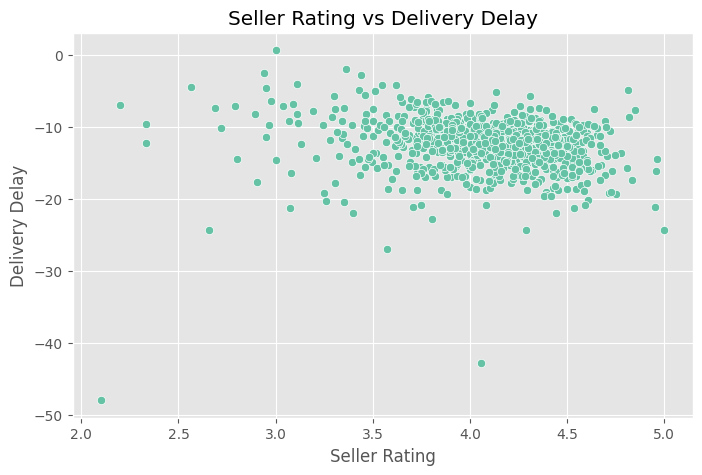

In [92]:
plt.figure(figsize=(8,5))

sns.scatterplot(
  data=seller_analysis,
  x="seller_rating",
  y="delivery_delay"
)

plt.title("Seller Rating vs Delivery Delay")
plt.xlabel("Seller Rating")
plt.ylabel("Delivery Delay")

plt.show()

#### Findings

- Most sellers have ratings between approximately **3.5 and 4.6**, with average delivery delays generally ranging from around **-8 to -18 days**.
- The scatter plot shows a **slight negative relationship** between seller rating and delivery delay, indicating that higher-rated sellers tend to have more negative delivery delays.
- Sellers with higher ratings generally appear to deliver orders **earlier**, while lower-rated sellers show greater variation in delivery performance.
- The concentration of sellers around higher ratings and negative delivery delays suggests that **better-rated sellers tend to maintain relatively stronger delivery performance**.
- However, the points are widely dispersed, indicating that **seller rating alone does not fully explain delivery performance**.
- Several sellers appear as **outliers**, with unusually large negative delivery delays despite varying seller ratings, suggesting that some sellers may have significantly different delivery practices or operational conditions.
- Overall, the analysis suggests that **seller quality and delivery performance are related, but other operational factors also contribute to delivery delays**.

## Section 5 — Marketplace Quality Analysis

## 5.1 Product Category Rating Distribution

### Objective

Analyze customer review scores across product categories to identify categories with consistently higher or lower customer satisfaction.

In [93]:
average_review_score_by_product_category=master_df.groupby("product_category_name")["review_score"].mean().sort_values(ascending=False).reset_index()

average_review_score_by_product_category

,product_category_name,review_score
0,cds_dvds_musicais,4.642857
1,fashion_roupa_infanto_juvenil,4.500000
2,livros_interesse_geral,4.446266
3,construcao_ferramentas_ferramentas,4.444444
4,flores,4.419355
...,...,...
68,moveis_escritorio,3.488372
69,pc_gamer,3.333333
70,portateis_cozinha_e_preparadores_de_alimentos,3.266667
71,fraldas_higiene,3.256410


In [95]:
top_10_review_score_by_product_category = average_review_score_by_product_category.head(10)

top_10_review_score_by_product_category



,product_category_name,review_score
0,cds_dvds_musicais,4.642857
1,fashion_roupa_infanto_juvenil,4.500000
2,livros_interesse_geral,4.446266
3,construcao_ferramentas_ferramentas,4.444444
4,flores,4.419355
5,livros_importados,4.400000
6,livros_tecnicos,4.363636
7,malas_acessorios,4.315257
8,alimentos_bebidas,4.310469
9,portateis_casa_forno_e_cafe,4.302632


In [96]:
bottom_10_review_score_by_product_category = average_review_score_by_product_category.tail(10)

bottom_10_review_score_by_product_category

,product_category_name,review_score
63,artigos_de_festas,3.767442
64,fashion_roupa_feminina,3.750000
65,telefonia_fixa,3.681992
66,fashion_roupa_masculina,3.641221
67,casa_conforto_2,3.629630
68,moveis_escritorio,3.488372
69,pc_gamer,3.333333
70,portateis_cozinha_e_preparadores_de_alimentos,3.266667
71,fraldas_higiene,3.256410
72,seguros_e_servicos,2.500000


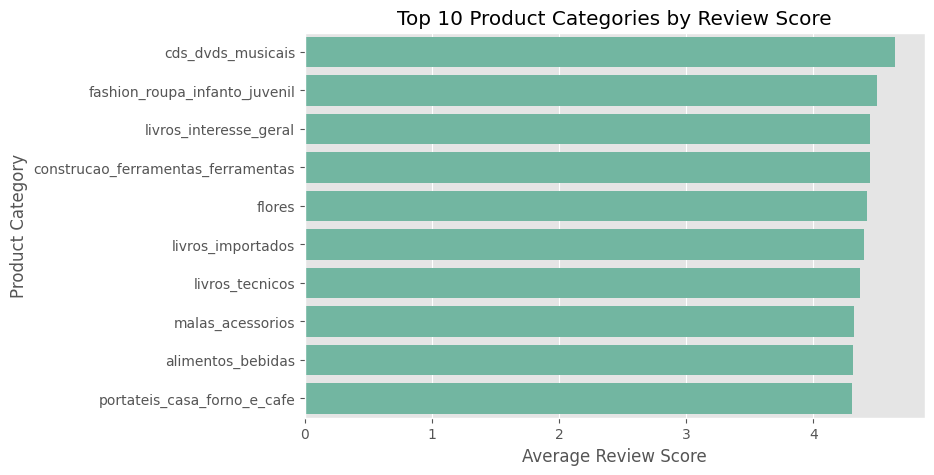

In [97]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=top_10_review_score_by_product_category,
    x="review_score",
    y="product_category_name"
)

plt.title("Top 10 Product Categories by Review Score")
plt.xlabel("Average Review Score")
plt.ylabel("Product Category")

plt.show()

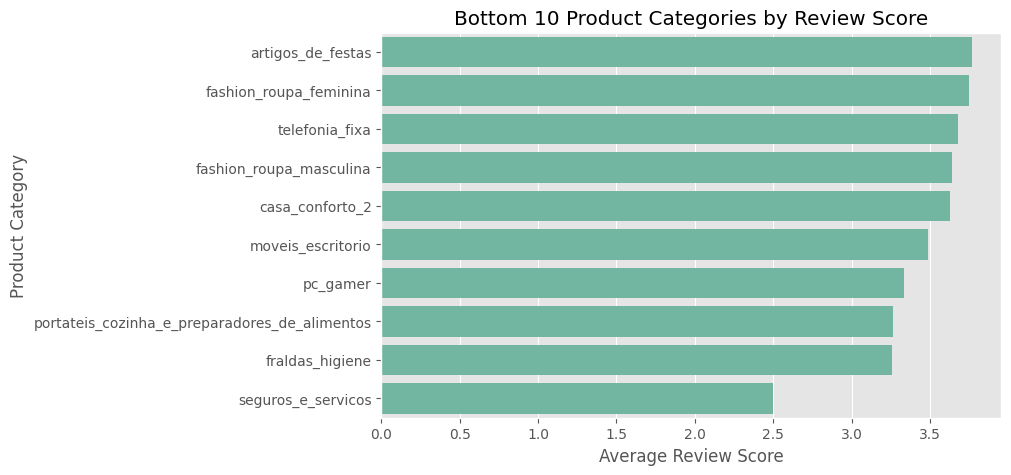

In [98]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=bottom_10_review_score_by_product_category,
    x="review_score",
    y="product_category_name"
)

plt.title("Bottom 10 Product Categories by Review Score")
plt.xlabel("Average Review Score")
plt.ylabel("Product Category")

plt.show()

#### Findings

- The `cds_dvds_musicais` product category had the highest average review score of **4.64**, indicating a very high level of customer satisfaction.
- Other highly rated categories included `fashion_roupa_infanto_juvenil` (**4.50**), `livros_interesse_geral` (**4.45**), and `construcao_ferramentas_ferramentas` (**4.44**).
- The top 10 product categories generally recorded average review scores above **4.30**, indicating consistently strong customer satisfaction among these categories.
- The `seguros_e_servicos` category had the lowest average review score of **2.50**, substantially lower than the other bottom-rated categories.
- Other lower-rated categories included `fraldas_higiene` (**3.26**), `portateis_cozinha_e_preparadores_de_alimentos` (**3.27**), and `pc_gamer` (**3.33**).
- The wide difference between the highest-rated category (**4.64**) and lowest-rated category (**2.50**) indicates that **customer satisfaction varies considerably across product categories**.
- Lower-rated product categories should be investigated further to identify whether factors such as delivery performance, product quality, or seller performance are contributing to lower customer satisfaction.

## 5.2 Seller Rating Distribution

### Objective

Analyze the distribution of seller ratings to understand the overall quality of sellers on the marketplace and identify whether seller ratings are generally concentrated at higher or lower levels.

In [99]:
seller_analysis["seller_rating"].describe()

count    887.000000
mean       4.067853
std        0.390458
min        2.100000
25%        3.869565
50%        4.115385
75%        4.333333
max        5.000000
Name: seller_rating, dtype: float64

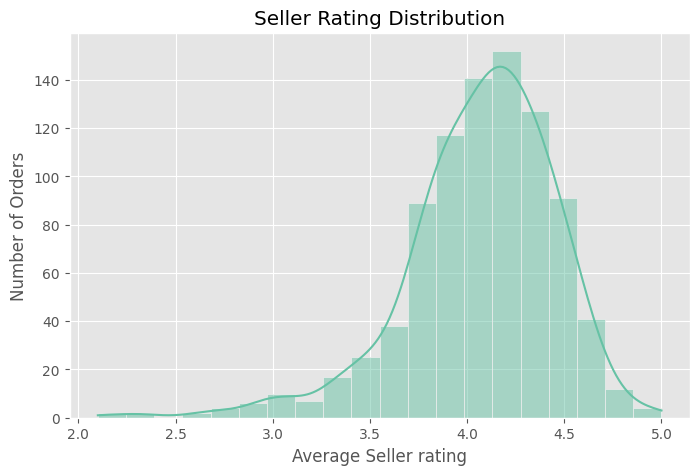

In [100]:
plt.figure(figsize=(8,5))

sns.histplot(
  data=seller_analysis,
  x="seller_rating",
  bins=20,
  kde=True
)

plt.title("Seller Rating Distribution")
plt.xlabel("Average Seller rating")
plt.ylabel("Number of Orders")

plt.show()

In [102]:
top_10_sellers = seller_analysis.sort_values(
    "seller_rating",
    ascending=False
).head(10)

top_10_sellers

,seller_id,seller_rating,review_count,delivery_delay
863,48efc9d94a9834137efd9ea76b065a38,5.000000,34,-24.352941
603,334cab711dee080b079fa5779b584783,4.961538,26,-14.461538
786,41c2bad7229b0c25e6becf179ebf63ff,4.956522,23,-16.043478
2138,b1fecf4da1fa2689bccffa0121953643,4.950000,20,-21.150000
577,30a81d8cf85fb2ada1b1b094c9583a95,4.850000,20,-7.600000
35,02f5837340d7eb4f653d676c7256523a,4.833333,30,-17.333333
2629,d9bd94811c3338dceb4181f3dbc0c73e,4.819672,61,-8.524590
2531,d13e50eaa47b4cbe9eb81465865d8cfc,4.811594,69,-4.808824
799,42fa4ee7240e9b8eb4576358ec142ba7,4.809524,21,-15.681818
1515,7ade73f1b9b4e965f9009a4c3a7e2c15,4.777778,27,-13.592593


In [103]:
bottom_10_sellers = seller_analysis.sort_values(
    "seller_rating",
    ascending=True
).head(10)

bottom_10_sellers

,seller_id,seller_rating,review_count,delivery_delay
3094,ffff564a4f9085cd26170f4732393726,2.100000,20,-48.000000
333,1ca7077d890b907f89be8c954a02686a,2.198529,136,-6.858268
1129,5bc55dbe2f12b6af6d83ed46023e0dc8,2.333333,21,-9.619048
1847,973f21788dfab357250f69a8dcb7ddee,2.333333,21,-12.157895
464,2709af9587499e95e803a6498a5a56e9,2.565217,46,-4.478261
2247,bb135baca94c82fcb731335ad5b04a03,2.657895,38,-24.315789
2856,ec4608a1f76453166bb312b2968aeaf4,2.685714,35,-7.275862
554,2eb70248d66e0e3ef83659f71b244378,2.716346,208,-10.121827
2132,b19f3ca2ea475913750f25a5c37c8d8f,2.791667,24,-7.052632
2727,e250d617a0ad591ba9bd663e584a895d,2.800000,20,-14.450000


#### Findings

- Seller ratings were calculated for **887 sellers** with at least 20 reviews, providing a more reliable assessment of seller performance.
- Seller ratings had an average of **4.07**, indicating that overall seller performance was generally positive.
- The median seller rating was **4.11**, showing that at least half of the sellers had ratings above approximately 4.1.
- The middle 50% of sellers had ratings between **3.87 and 4.33**, indicating that most sellers were concentrated within a relatively high-rating range.
- Seller ratings ranged from **2.10 to 5.00**, showing that although most sellers performed well, there were some significantly lower-rated sellers.
- The histogram shows that seller ratings are strongly concentrated around **4.0–4.5**, with relatively few sellers receiving very low ratings.
- Overall, the marketplace shows **generally strong seller performance**, but the lower-rated sellers may require further investigation to identify potential quality or service issues.

## 5.3 Seller Performance Matrix

### Objective

Evaluate seller performance by comparing seller ratings with average delivery delay to identify high-performing and underperforming sellers.

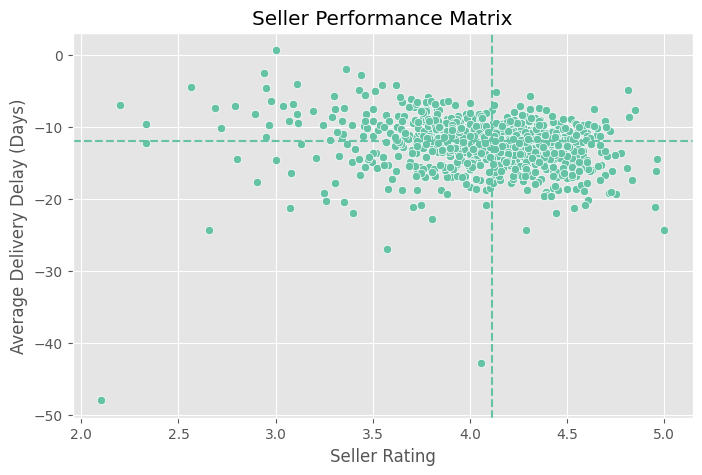

In [104]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=seller_analysis,
    x="seller_rating",
    y="delivery_delay"
)

plt.title("Seller Performance Matrix")
plt.xlabel("Seller Rating")
plt.ylabel("Average Delivery Delay (Days)")

plt.axvline(seller_analysis["seller_rating"].median(), linestyle="--")
plt.axhline(seller_analysis["delivery_delay"].median(), linestyle="--")

plt.show()

#### Findings

- Most sellers were concentrated around **4.0–4.5 in seller rating**, indicating generally strong seller performance across the marketplace.
- The majority of sellers had **negative average delivery delays**, meaning that orders were generally delivered earlier than the estimated delivery date.
- Higher-rated sellers generally maintained early delivery performance, but the scatter plot does not show a strong relationship between **seller rating and delivery delay**.
- Lower-rated sellers showed **greater variation in delivery performance**, with some sellers experiencing relatively higher delivery delays compared with the main seller population.
- A small number of sellers had unusually large negative delivery delays, indicating **potentially exceptional early deliveries or outlier behavior**.
- Overall, **seller rating alone does not appear to be a strong predictor of delivery performance**, suggesting that other operational factors may also influence delivery delays.

## 5.4 Product Category vs Delivery Delay

### Objective

Analyze average delivery delay across product categories to identify categories that experience relatively higher or lower delivery delays.

In [105]:
average_delivery_delay_by_product_category=master_df.groupby("product_category_name")["delivery_delay"].mean().sort_values(ascending=False).reset_index()

average_delivery_delay_by_product_category

,product_category_name,delivery_delay
0,artes_e_artesanato,-6.791667
1,moveis_colchao_e_estofado,-7.162162
2,casa_conforto_2,-8.433333
3,portateis_cozinha_e_preparadores_de_alimentos,-9.500000
4,pc_gamer,-9.625000
...,...,...
68,artigos_de_festas,-15.119048
69,fashion_roupa_infanto_juvenil,-15.714286
70,la_cuisine,-16.357143
71,cds_dvds_musicais,-16.857143


In [107]:
top_10_delivery_delay_by_product_category = (
    average_delivery_delay_by_product_category
    .head(10)
)

top_10_delivery_delay_by_product_category

,product_category_name,delivery_delay
0,artes_e_artesanato,-6.791667
1,moveis_colchao_e_estofado,-7.162162
2,casa_conforto_2,-8.433333
3,portateis_cozinha_e_preparadores_de_alimentos,-9.500000
4,pc_gamer,-9.625000
5,casa_conforto,-9.811189
6,alimentos,-9.867735
7,audio,-10.149171
8,fashion_underwear_e_moda_praia,-10.929134
9,eletronicos,-11.139978


In [108]:
bottom_10_delivery_delay_by_product_category=(
  average_delivery_delay_by_product_category
  .tail(10)
)

bottom_10_delivery_delay_by_product_category

,product_category_name,delivery_delay
63,climatizacao,-14.169550
64,musica,-14.342105
65,market_place,-14.622951
66,telefonia_fixa,-14.717647
67,fashion_calcados,-14.832685
68,artigos_de_festas,-15.119048
69,fashion_roupa_infanto_juvenil,-15.714286
70,la_cuisine,-16.357143
71,cds_dvds_musicais,-16.857143
72,seguros_e_servicos,-17.000000


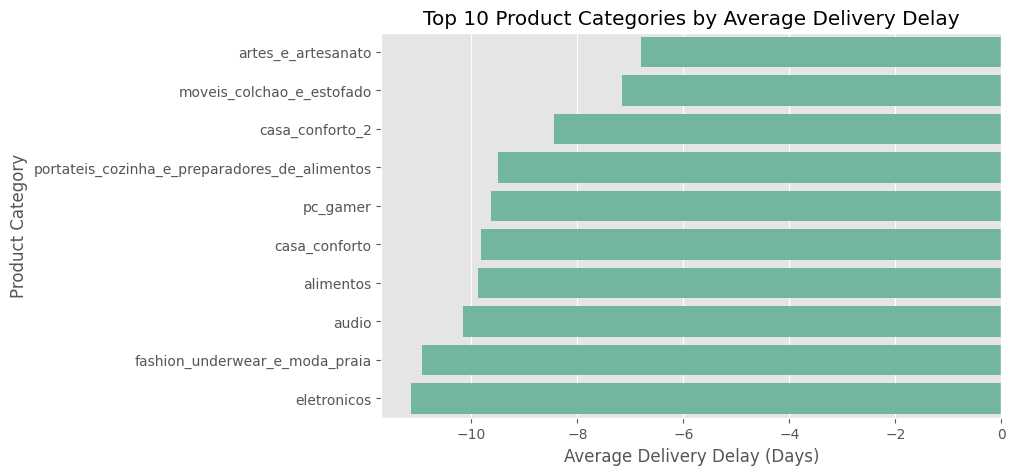

In [110]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=top_10_delivery_delay_by_product_category,
    x="delivery_delay",
    y="product_category_name"
)

plt.title("Top 10 Product Categories by Average Delivery Delay")
plt.xlabel("Average Delivery Delay (Days)")
plt.ylabel("Product Category")

plt.show()

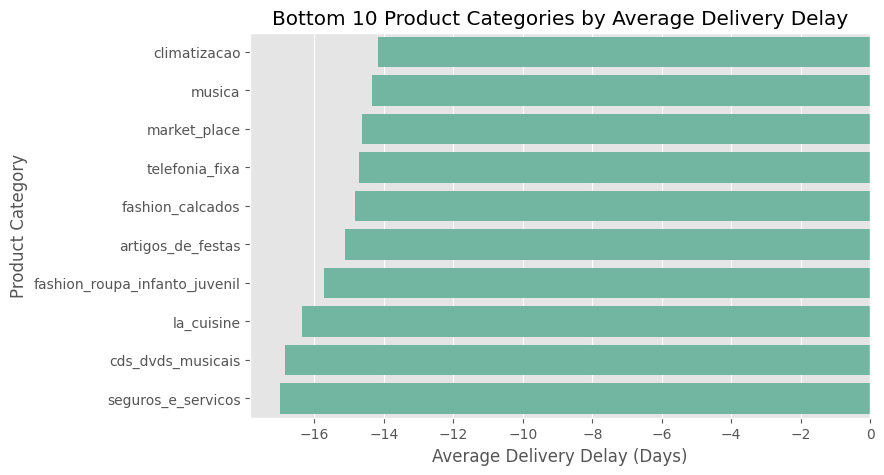

In [111]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=bottom_10_delivery_delay_by_product_category,
    x="delivery_delay",
    y="product_category_name"
)

plt.title("Bottom 10 Product Categories by Average Delivery Delay")
plt.xlabel("Average Delivery Delay (Days)")
plt.ylabel("Product Category")

plt.show()

#### Findings

- All of the top and bottom product categories shown had **negative average delivery delays**, indicating that orders across these categories were generally delivered earlier than the estimated delivery date.
- Among the categories with the least negative delivery delays, **artes_e_artesanato** had an average delay of approximately **-6.79 days**, followed by **moveis_colchao_e_estofado** at **-7.16 days**.
- **eletronicos** had one of the more negative average delivery delays among the top categories, at approximately **-11.14 days**, indicating that these orders were delivered substantially earlier than estimated.
- Among the categories with the earliest average deliveries, **seguros_e_servicos** had the most negative delay at **-17.00 days**, followed by **cds_dvds_musicais** at **-16.86 days** and **la_cuisine** at **-16.36 days**.
- The difference in average delivery delay across product categories indicates that **delivery performance varies considerably by product category**.
- Product categories with relatively smaller negative delays may have less delivery buffer compared with categories that are delivered much earlier than estimated.
- Overall, **product category appears to be associated with differences in delivery performance**, suggesting that category-specific logistics and fulfillment characteristics may influence delivery timing.

## Section 6 — Correlation Analysis


### Objective

Analyze the relationships between key numerical variables to identify factors that are strongly associated with delivery performance and customer experience.

In [114]:
correlation_data = master_df[
    [
        "review_score",
        "delivery_time",
        "delivery_delay",
        "freight_value",
        "seller_rating"
    ]
]

correlation_data.corr()

,review_score,delivery_time,delivery_delay,freight_value,seller_rating
review_score,1.000000,-0.304644,-0.229228,-0.036161,NaN
delivery_time,-0.304644,1.000000,0.597315,0.214631,NaN
delivery_delay,-0.229228,0.597315,1.000000,-0.040242,NaN
freight_value,-0.036161,0.214631,-0.040242,1.000000,NaN
seller_rating,NaN,NaN,NaN,NaN,NaN


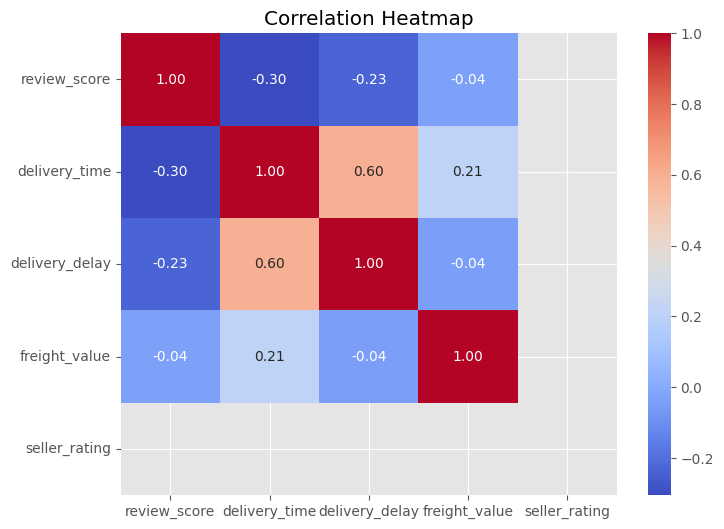

In [115]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_data.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

#### Findings

- Delivery time and delivery delay showed the strongest relationship among the variables analyzed, with a correlation of **0.60**, indicating that longer delivery times are moderately associated with greater delivery delays.
- Review score had a **-0.30** correlation with delivery time, suggesting that longer delivery times are generally associated with lower customer review scores.
- Review score and delivery delay showed a **-0.23** correlation, indicating that greater delivery delays are associated with lower customer satisfaction, although the relationship is relatively weak.
- Freight value had a weak positive correlation of **0.21** with delivery time, suggesting that higher freight costs are slightly associated with longer delivery times.
- Freight value showed negligible correlations with review score (**-0.04**) and delivery delay (**-0.04**), indicating little observable linear relationship between shipping cost and these factors.
- Overall, the correlation analysis indicates that **delivery performance is more closely associated with customer satisfaction than freight cost**, with delivery time and delivery delay showing the most relevant relationships.
- Seller rating returned **NaN** correlations because there were no overlapping valid observations for this variable in the correlation dataset; therefore, no conclusion about the relationship between seller rating and the other variables should be drawn from this heatmap.

## Section 7 — Business Recommendations

### 7.1 Prioritize Late Delivery Reduction

- Although approximately **91.89% of delivered orders were delivered on or before the estimated delivery date**, the remaining delayed orders have a significant impact on customer satisfaction. :contentReference[oaicite:0]{index=0}
- Late deliveries received substantially lower review scores than early and on-time deliveries, indicating that delivery delays are an important customer-experience issue.
- The business should focus on identifying the operational causes of late deliveries and reducing the frequency of severe delays.

### 7.2 Improve Logistics in High-Delay Regions

- Delivery performance varies considerably across customer states, with **Roraima, Amapá, and Amazonas** recording longer average delivery times than states such as **São Paulo, Paraná, and Minas Gerais**. :contentReference[oaicite:1]{index=1}
- The business should prioritize logistics improvements in consistently slower regions through better shipping routes, regional fulfillment strategies, and improved distribution planning.

### 7.3 Develop Category-Specific Fulfillment Strategies

- Delivery performance differs substantially across product categories, indicating that a single fulfillment strategy may not be equally effective for all categories.
- Categories with longer delivery times should be reviewed for factors such as supplier location, inventory availability, product handling requirements, and shipping distance.
- Category-specific fulfillment strategies can help reduce delivery times while maintaining service quality.

### 7.4 Address Low Customer Satisfaction Categories

- Product categories show considerable variation in average review scores, with some categories achieving consistently high customer satisfaction while others record substantially lower ratings.
- The business should investigate lower-rated categories to determine whether poor ratings are associated with product quality, delivery experience, or seller performance.
- Practices from highly rated categories can be studied and replicated where appropriate. The analysis identifies categories such as **cds_dvds_musicais** with average review scores above 4.6, providing useful benchmarks for comparison. :contentReference[oaicite:2]{index=2}

### 7.5 Monitor and Support Underperforming Sellers

- Seller performance varies considerably, with some sellers maintaining average customer review scores above **4.70**, while others remain between approximately **2.10 and 3.10** despite having sufficient review counts. :contentReference[oaicite:3]{index=3}
- High-performing sellers should be recognized and their successful practices studied.
- Underperforming sellers should receive targeted quality-improvement support, with continued monitoring of customer feedback and delivery performance.

### 7.6 Focus on Delivery Time as a Key Customer Experience Metric

- The correlation analysis shows a **-0.30 correlation between review score and delivery time**, while delivery time and delivery delay have a **0.60 correlation**.
- This indicates that longer delivery times are associated with lower customer satisfaction and are also closely related to delivery delays.
- The business should therefore monitor delivery time and delay together as key operational performance indicators.

### 7.7 Maintain Strengths While Improving Exceptions

- The marketplace demonstrates generally strong performance, with approximately **91.89% of delivered orders meeting or beating the estimated delivery date** and an average customer review score above **4 out of 5**. :contentReference[oaicite:4]{index=4}
- Therefore, the primary objective should not be to redesign the entire delivery system, but to identify and reduce the specific **regional, category, seller, and order-level exceptions** that contribute to poor customer experiences.